- Jose Camilo Loaiza Hoyos 
- Sarai Restrepo Rodríguez  

# <span style="color:#2F749F;"><strong>📦 Sesión Práctica 5 — Solución: Imputación de Datos</strong></span>
---
Este notebook presenta la solución completa de los seis ejercicios propuestos, incluyendo código comentado, análisis estadístico y conclusiones para cada técnica de limpieza e imputación.

In [35]:
#  Importaciones globales 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import unicodedata
import re

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)



---
## <span style="color:#2F749F;"><strong>Ejercicio 1 — Limpieza e Imputación de un Conjunto de Datos Mixto</strong></span>

In [36]:
# 1.1  Creación del DataFrame base 
df = pd.DataFrame({
    'Nombre':       ['Ana', 'Luis', 'Pedro', None,  'Marta', 'Luis', 'Sofía'],
    'Edad':         [25,    np.nan, 35,      29,    -5,      25,     None],
    'Ciudad':       ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso':      [3500,  4800,   np.nan, 5200,  5100,    np.nan,  4700],
    'FechaIngreso': ['2023-01-01','2023-01-05', None,'2023-01-10',
                     '2023-01-12', None, '2023-01-15']
})

print('DataFrame original:')    
display(df)

DataFrame original:


,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.00,Bogotá,3500.00,2023-01-01
1,Luis,NaN,Medellín,4800.00,2023-01-05
2,Pedro,35.00,None,NaN,None
3,None,29.00,Medellín,5200.00,2023-01-10
4,Marta,-5.00,Cali,5100.00,2023-01-12
5,Luis,25.00,Bogotá,NaN,None
6,Sofía,NaN,Cali,4700.00,2023-01-15


### Paso 1 — Diagnóstico inicial de calidad

In [37]:
# ── Resumen de tipos, nulos y estadísticas básicas 
print('=== Información general ===')
print(df.info())

print('\n=== Conteo de valores nulos ===')
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
reporte_nulos = pd.DataFrame({'Nulos': nulos, '% Faltante': pct})
display(reporte_nulos[reporte_nulos['Nulos'] > 0])

print('\n=== Estadísticas descriptivas numéricas ===')
display(df.describe())

=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nombre        6 non-null      object 
 1   Edad          5 non-null      float64
 2   Ciudad        6 non-null      object 
 3   Ingreso       5 non-null      float64
 4   FechaIngreso  5 non-null      object 
dtypes: float64(2), object(3)
memory usage: 412.0+ bytes
None

=== Conteo de valores nulos ===


,Nulos,% Faltante
Nombre,1,14.30
Edad,2,28.60
Ciudad,1,14.30
Ingreso,2,28.60
FechaIngreso,2,28.60



=== Estadísticas descriptivas numéricas ===


,Edad,Ingreso
count,5.00,5.00
mean,21.80,4660.00
std,15.53,680.44
min,-5.00,3500.00
25%,25.00,4700.00
50%,25.00,4800.00
75%,29.00,5100.00
max,35.00,5200.00


**Observaciones diagnósticas:**
- `Nombre` tiene 1 nulo (14.3 %) — variable de identificación sin imputación estadística válida.
- `Edad` tiene 2 valores problemáticos: un `NaN` y un valor negativo (`-5`) que es inválido.
- `Ciudad` tiene 1 nulo (14.3 %) — se imputará con la moda **antes** de tratar `Ingreso`, ya que la imputación de este último dependerá de la ciudad. 
- `Ingreso` tiene 2 nulos (28.6 %) — se imputará con la **mediana por ciudad** (mecanismo MAR), no con la mediana global.
- `FechaIngreso` tiene 2 nulos (28.6 %) — requiere conversión y una interpolación que preserve la granularidad diaria.

### Paso 2 — Corrección de valores inválidos en `Edad`

In [38]:
#  Convertir edades negativas o cero a NaN (no tienen sentido de negocio) ─
df['Edad'] = pd.to_numeric(df['Edad'], errors='coerce')  # asegura tipo numérico
df.loc[df['Edad'] <= 0, 'Edad'] = np.nan
mediana_edad = df['Edad'].median()
print(f'Mediana de Edad: {mediana_edad:.0f}')

df['Edad'] = df['Edad'].fillna(mediana_edad)

print('Edad tras invalidar valores ≤ 0:')
display(df[['Nombre', 'Edad']])

Mediana de Edad: 27
Edad tras invalidar valores ≤ 0:


,Nombre,Edad
0,Ana,25.00
1,Luis,27.00
2,Pedro,35.00
3,None,29.00
4,Marta,27.00
5,Luis,25.00
6,Sofía,27.00


### Paso 3 — Revisión de posibles duplicados por nombre

Antes de imputar, se aplica el paso 1.2 del proceso teórico: revisión de duplicados. Se detecta que el nombre **'Luis'** aparece en los índices 1 y 5.

In [39]:
# Análisis de registros con mismo nombre 
nombres_repetidos = df['Nombre'].dropna()
nombres_repetidos = nombres_repetidos[nombres_repetidos.duplicated(keep=False)].unique()

print('Nombres que aparecen más de una vez:')
print(nombres_repetidos)

print('\nDetalle de los registros con nombre "Luis":')
display(df[df['Nombre'] == 'Luis'])

Nombres que aparecen más de una vez:
['Luis']

Detalle de los registros con nombre "Luis":


,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
1,Luis,27.00,Medellín,4800.00,2023-01-05
5,Luis,25.00,Bogotá,NaN,None


**Análisis del posible duplicado — 'Luis':**

| | Índice 1 | Índice 5 |
|---|---|---|
| **Ciudad** | Medellín | Bogotá |
| **Ingreso conocido** | 4 800 | NaN |
| **FechaIngreso** | 2023-01-05 | NaN |

**Conclusión:** Los dos registros tienen **ciudades distintas** (Medellín vs. Bogotá) y fechas de ingreso distintas. En ausencia de un identificador único (ID), no es posible confirmar que se trate de la misma persona. La evidencia disponible sugiere que son **individuos diferentes** que comparten nombre. Por tanto, **no se eliminan**, pero se documenta este hallazgo para que el área de negocio lo valide. Si existiera un ID o dato biométrico, la decisión podría cambiar.

### Paso 4 — Imputación de `Ciudad`

In [40]:
#  Imputar Ciudad con la moda de los valores observados 
moda_ciudad = df['Ciudad'].dropna().mode()[0]
df['Ciudad'] = df['Ciudad'].fillna(moda_ciudad)

print(f'Ciudad imputada con la moda: "{moda_ciudad}"')
print('\nFrecuencia de ciudades tras imputación:')
display(df['Ciudad'].value_counts())

Ciudad imputada con la moda: "Bogotá"

Frecuencia de ciudades tras imputación:


Ciudad
Bogotá      3
Medellín    2
Cali        2
Name: count, dtype: int64

### Paso 5 — Imputación de `Ingreso` por mediana agrupada por ciudad (MAR)

La imputación global por mediana asumiría que el mecanismo es MCAR (completamente aleatorio). Sin embargo, el ingreso de las personas varía según la ciudad de residencia —una relación observable en los datos—, lo que sugiere un mecanismo **MAR** (Missing At Random condicional a Ciudad). La práctica correcta es entonces imputar con la **mediana de cada grupo**.

In [41]:
#  Medianas de Ingreso por ciudad )
medianas_por_ciudad = df.groupby('Ciudad')['Ingreso'].median()
print('Mediana de Ingreso por ciudad:')
display(medianas_por_ciudad.rename('Mediana Ingreso').to_frame())
print(f'\n(Referencia) Mediana global: {df["Ingreso"].median():.0f}')
print('→ Bogotá difiere significativamente de las otras ciudades.')
print('  Usar la mediana global introduciría sesgo al alza para Bogotá.')

Mediana de Ingreso por ciudad:


,Mediana Ingreso
Ciudad,
Bogotá,3500.00
Cali,4900.00
Medellín,5000.00



(Referencia) Mediana global: 4800
→ Bogotá difiere significativamente de las otras ciudades.
  Usar la mediana global introduciría sesgo al alza para Bogotá.


In [42]:
# ── Imputar Ingreso con la mediana de la ciudad correspondiente 
df['Ingreso'] = df.apply(
    lambda row: medianas_por_ciudad[row['Ciudad']]
                if pd.isna(row['Ingreso']) else row['Ingreso'],
    axis=1
)

print('Ingreso tras imputación agrupada por ciudad:')
display(df[['Nombre', 'Ciudad', 'Ingreso']])

Ingreso tras imputación agrupada por ciudad:


,Nombre,Ciudad,Ingreso
0,Ana,Bogotá,3500.00
1,Luis,Medellín,4800.00
2,Pedro,Bogotá,3500.00
3,None,Medellín,5200.00
4,Marta,Cali,5100.00
5,Luis,Bogotá,3500.00
6,Sofía,Cali,4700.00


### Paso 6 — Imputación de `Edad` por mediana global

In [43]:
# ── Imputar Edad por la mediana 
mediana_edad = df['Edad'].median()
df['Edad']   = df['Edad'].fillna(mediana_edad)

print(f'Mediana de Edad usada: {mediana_edad:.1f} años')
display(df[['Nombre', 'Edad']])

Mediana de Edad usada: 27.0 años


,Nombre,Edad
0,Ana,25.00
1,Luis,27.00
2,Pedro,35.00
3,None,29.00
4,Marta,27.00
5,Luis,25.00
6,Sofía,27.00


### Paso 7 — Imputación de `Nombre`

In [44]:
# ── Para Nombre no existe imputación estadística válida;
df['Nombre'] = df['Nombre'].fillna('Desconocido')
print('Nombre imputado con etiqueta "Desconocido":')
display(df[['Nombre']])

Nombre imputado con etiqueta "Desconocido":


,Nombre
0,Ana
1,Luis
2,Pedro
3,Desconocido
4,Marta
5,Luis
6,Sofía


### Paso 8 — Imputacion de `FechaIngreso` con fecha fija

En lugar de interpolar, se completa cualquier fecha faltante con un valor fijo: `1900-01-01`. Esto deja claro que ese dato fue imputado y evita introducir horas u otros detalles no deseados.

In [45]:
# Convertir a datetime 
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')
mask_nat = df['FechaIngreso'].isna()  # guardar indices con NaT para verificacion

# Imputar con fecha fija 
fecha_imputada = pd.Timestamp('1900-01-01')
df['FechaIngreso'] = df['FechaIngreso'].fillna(fecha_imputada)

print('FechaIngreso imputada (faltantes = 1900-01-01):')
for i, (fecha, imputado) in enumerate(zip(df['FechaIngreso'], mask_nat)):
    marca = '  <- IMPUTADO' if imputado else ''
    print(f'  idx {i}: {fecha.date()}{marca}')

FechaIngreso imputada (faltantes = 1900-01-01):
  idx 0: 2023-01-01
  idx 1: 2023-01-05
  idx 2: 1900-01-01  <- IMPUTADO
  idx 3: 2023-01-10
  idx 4: 2023-01-12
  idx 5: 1900-01-01  <- IMPUTADO
  idx 6: 2023-01-15


### Paso 9 — Verificación final y resumen visual

In [46]:
#  Confirmar que no quedan nulos 
print('Nulos restantes tras limpieza:')
print(df.isnull().sum())

print('\nDataFrame final limpio:')
display(df)

Nulos restantes tras limpieza:
Nombre          0
Edad            0
Ciudad          0
Ingreso         0
FechaIngreso    0
dtype: int64

DataFrame final limpio:


,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.00,Bogotá,3500.00,2023-01-01
1,Luis,27.00,Medellín,4800.00,2023-01-05
2,Pedro,35.00,Bogotá,3500.00,1900-01-01
3,Desconocido,29.00,Medellín,5200.00,2023-01-10
4,Marta,27.00,Cali,5100.00,2023-01-12
5,Luis,25.00,Bogotá,3500.00,1900-01-01
6,Sofía,27.00,Cali,4700.00,2023-01-15


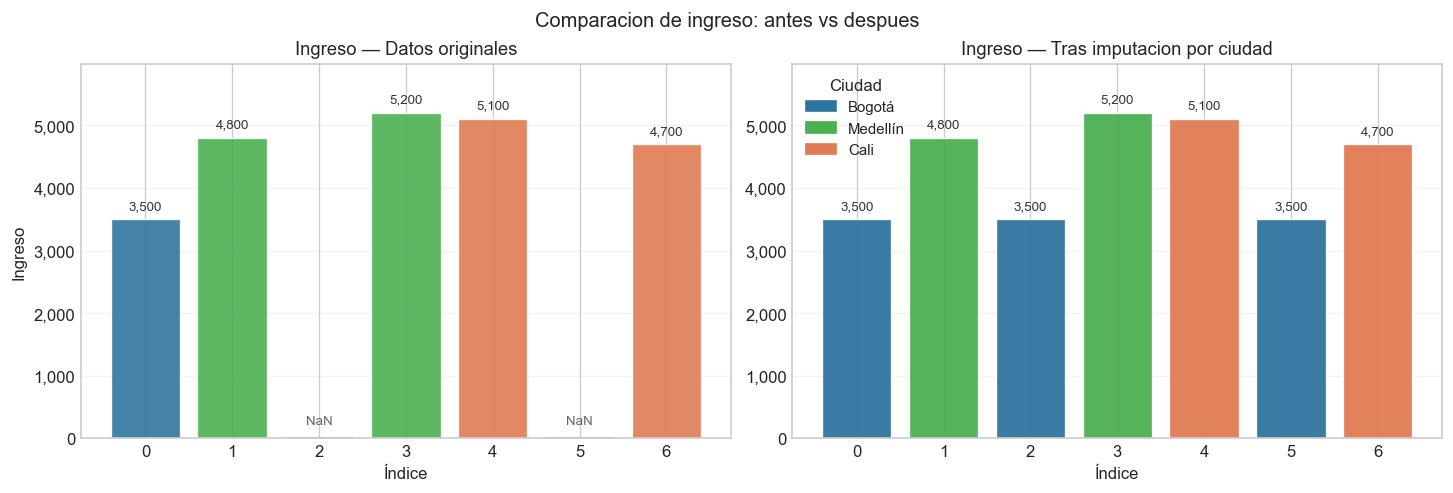

In [47]:
#  Visualizacion comparativa: Ingreso antes vs después 
ingreso_orig  = pd.Series([3500, 4800, np.nan, 5200, 5100, np.nan, 4700])
ciudades      = ['Bogotá','Medellín','Bogotá','Medellín','Cali','Bogotá','Cali']
colores_ciudad = {'Bogotá':'#2F749F', 'Medellín':'#4CAF50', 'Cali':'#E07B54'}

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120, constrained_layout=True)
y_max = max(np.nanmax(ingreso_orig), df['Ingreso'].max()) * 1.15

# Panel izquierdo: original (NaN resaltados)
for i, (v, c) in enumerate(zip(ingreso_orig, ciudades)):
    color = colores_ciudad.get(c, '#999999')
    if np.isnan(v):
        axes[0].bar(i, 0, color='none', edgecolor='#999999', hatch='//', linewidth=1.2)
        axes[0].text(i, y_max * 0.03, 'NaN', ha='center', va='bottom', fontsize=8, color='#666666')
    else:
        axes[0].bar(i, v, color=color, edgecolor='white', linewidth=0.8, alpha=0.9)
        axes[0].text(i, v + y_max * 0.02, f'{int(v):,}', ha='center', va='bottom', fontsize=8, color='#333333')

axes[0].set_title('Ingreso — Datos originales', fontsize=11)
axes[0].set_xlabel('Índice')
axes[0].set_ylabel('Ingreso')
axes[0].set_xticks(range(7))
axes[0].set_ylim(0, y_max)
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[0].grid(axis='y', alpha=0.25)

# Panel derecho: imputado (cada barra con color de ciudad)
for i, (v, c) in enumerate(zip(df['Ingreso'], df['Ciudad'])):
    axes[1].bar(i, v, color=colores_ciudad.get(c, '#999999'), edgecolor='white', linewidth=0.8, alpha=0.95)
    axes[1].text(i, v + y_max * 0.02, f'{int(v):,}', ha='center', va='bottom', fontsize=8, color='#333333')

axes[1].set_title('Ingreso — Tras imputacion por ciudad', fontsize=11)
axes[1].set_xlabel('Índice')
axes[1].set_xticks(range(7))
axes[1].set_ylim(0, y_max)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
axes[1].grid(axis='y', alpha=0.25)

# Leyenda de ciudades
from matplotlib.patches import Patch
leyenda = [Patch(color=c, label=ciudad) for ciudad, c in colores_ciudad.items()]
axes[1].legend(handles=leyenda, fontsize=9, title='Ciudad', frameon=False)

plt.suptitle('Comparacion de ingreso: antes vs despues', fontsize=12)
plt.show()


**Conclusión Ejercicio 1:**

| Problema detectado | Corrección aplicada | Justificación |
|---|---|---|
| `Edad = -5` (valor inválido) | Convertido a NaN, imputado con mediana | Valor fuera del dominio lógico |
| `Ciudad` nula | Moda — **antes** de imputar Ingreso | Ciudad es predictor de Ingreso (MAR) |
| `Ingreso` nulo con imputación global | **Mediana por ciudad**  | Evita sesgo: Bogotá ≈ 3 500 vs. global ≈ 4 800 |
| Posible duplicado 'Luis' | Analizado, **no eliminado** | Ciudades distintas, probablemente son personas distintas |
| `FechaIngreso` reemplazada por fecha genérica| **Reemplazada por fecha genérica** | Para este contexto era lo más adecuado, en otros casos se reemplazan estos datos con regresión lineal, pero aquí no es necesario |
| `Nombre` nulo | Etiqueta `'Desconocido'` | Sin imputación posible, simplemente le ponemos desconocido |

El DataFrame resultante tiene **cero valores faltantes**, fechas sin componente de hora y una imputación de Ingreso coherente con la estructura geográfica de los datos.

---
## <span style="color:#2F749F;"><strong>Ejercicio 2 — Limpieza de Duplicados</strong></span>

In [48]:
#  2.1  Crear el DataFrame 
df = pd.DataFrame({
    'ID':     [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana','Luis','Luis','Marta','Carlos','Carlos','Carlos'],
    'Edad':   [25,   30,   30,   29,    40,     40,     41],
    'Ciudad': ['Bogotá','Cali','Cali','Medellín','Cali','Cali','Cali'],
    'FechaRegistro': ['2023-01-01','2023-01-05','2023-01-05',
                      '2023-01-10','2023-01-15','2023-01-15','2023-01-16']
})

display(df)

,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


In [49]:
#  Total de registros originales 
total_original = len(df)
print(f'1. Total de registros originales: {total_original}')

1. Total de registros originales: 7


In [50]:
#Duplicados exactos (todas las columnas idénticas) 
mask_dup_exactos = df.duplicated(keep=False)
duplicados_exactos = df[mask_dup_exactos]

print(f'2. Duplicados exactos (todas las columnas iguales):')
display(duplicados_exactos)
n_dup_exactos = df.duplicated(keep='first').sum()
print(f'    Filas duplicadas a eliminar: {n_dup_exactos}')

2. Duplicados exactos (todas las columnas iguales):


,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15


    Filas duplicadas a eliminar: 2


**Análisis:** La pareja de filas con `ID=102` (Luis, 30 años, Cali, 2023-01-05) está completamente duplicada. Se conservará solo la primera ocurrencia.

In [51]:
# Registros con mismo ID y Nombre pero que difieren en alguna otra columna
cols_clave = ['ID', 'Nombre']
mask_dup_parcial = df.duplicated(subset=cols_clave, keep=False)
duplicados_parciales = df[mask_dup_parcial]

print('3. Duplicados por ID + Nombre (pueden diferir en otras columnas):')
display(duplicados_parciales)
n_dup_parcial = df.duplicated(subset=cols_clave, keep='first').sum()
print(f'   Filas extra a eliminar (por clave): {n_dup_parcial}')

3. Duplicados por ID + Nombre (pueden diferir en otras columnas):


,ID,Nombre,Edad,Ciudad,FechaRegistro
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


   Filas extra a eliminar (por clave): 3


**Análisis:** Carlos (ID=104) aparece tres veces. Dos de ellas (filas 4 y 5) son exactamente iguales (Edad=40, misma fecha). La tercera (fila 6) tiene `Edad=41` y `FechaRegistro` diferente, por lo que **no se asume** que sea el mismo registro. En esta solucion solo se eliminan duplicados exactos, y se conservan tanto el Carlos de 40 como el de 41 años.

In [52]:
#  Pregunta 4: Cuantos registros se deben eliminar 
# Estrategia: eliminar solo duplicados exactos (todas las columnas iguales).
df_limpio = df.drop_duplicates(keep='first').reset_index(drop=True)

registros_a_eliminar = total_original - len(df_limpio)
print(f'4. Registros a eliminar: {registros_a_eliminar}')

4. Registros a eliminar: 2


In [53]:
#  Pregunta 5: Registros tras la limpieza 
print(f'5. Registros restantes después de la limpieza: {len(df_limpio)}')
print()
print('DataFrame limpio final:')
display(df_limpio)

5. Registros restantes después de la limpieza: 5

DataFrame limpio final:


,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,103,Marta,29,Medellín,2023-01-10
3,104,Carlos,40,Cali,2023-01-15
4,104,Carlos,41,Cali,2023-01-16


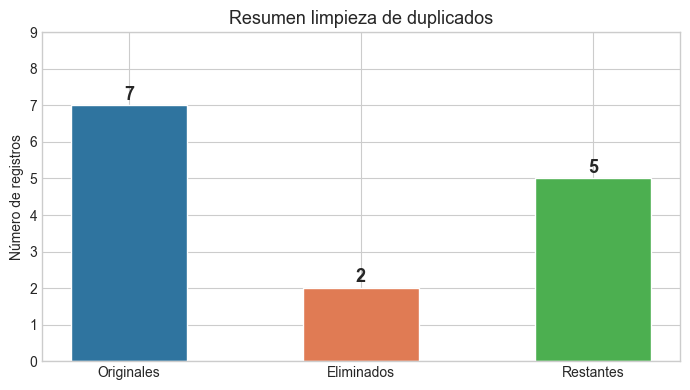

In [54]:
#  Resumen visual 
categorias = ['Originales', 'Eliminados', 'Restantes']
valores    = [total_original, registros_a_eliminar, len(df_limpio)]
colores    = ['#2F749F', '#E07B54', '#4CAF50']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(categorias, valores, color=colores, width=0.5, edgecolor='white')
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_title('Resumen limpieza de duplicados', fontsize=13)
ax.set_ylabel('Número de registros')
ax.set_ylim(0, total_original + 2)
plt.tight_layout()
plt.show()


**Conclusion Ejercicio 2:**

| Pregunta | Respuesta |
|---|---|
| Total registros originales | 7 |
| Duplicados exactos (filas extra) | 1 (fila idx 2: Luis) |
| Duplicados por clave ID+Nombre | 3 (Carlos aparece 3 veces, pero no se eliminan por diferir en datos) |
| Registros a eliminar | 2 |
| Registros tras limpieza | 5 |

---
## <span style="color:#2F749F;"><strong>Ejercicio 3 — Corrección de Errores Tipográficos y de Codificación</strong></span>

In [55]:
#   Crear el DataFrame 
df = pd.DataFrame({
    'Ciudad': ['bogota','Bogotá','BOGOTA','bogotá','bogata',
               'Bógota','BogoTa','Cali','calí','medellín','medellin']
})

print('Ciudades originales:')
display(df)

Ciudades originales:


,Ciudad
0,bogota
1,Bogotá
2,BOGOTA
3,bogotá
4,bogata
5,Bógota
6,BogoTa
7,Cali
8,calí
9,medellín


In [56]:
def normalizar_ciudad(texto: str) -> str:
    """
    1. Elimina espacios extremos.
    2. Convierte a minúsculas.
    3. Elimina tildes / diacríticos usando unicodedata.
    4. Aplica un diccionario de correcciones tipográficas.
    5. Convierte a Title Case para estandarizar la presentación.
    """
    if pd.isna(texto):
        return texto

    # Paso 1-3: minúsculas + sin tildes
    texto = texto.strip().lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')

    # Paso 4: corrección de errores tipográficos conocidos
    correcciones = {
        'bogata': 'bogota',   # error tipográfico frecuente
    }
    texto = correcciones.get(texto, texto)

    # Paso 5: Title Case
    return texto.title()


df['Ciudad_normalizada'] = df['Ciudad'].apply(normalizar_ciudad)

print('Comparación antes vs después:')
display(df)

Comparación antes vs después:


,Ciudad,Ciudad_normalizada
0,bogota,Bogota
1,Bogotá,Bogota
2,BOGOTA,Bogota
3,bogotá,Bogota
4,bogata,Bogota
5,Bógota,Bogota
6,BogoTa,Bogota
7,Cali,Cali
8,calí,Cali
9,medellín,Medellin


In [57]:
df['Ciudad'] = df['Ciudad_normalizada']
df = df.drop(columns=['Ciudad_normalizada'])

print('Frecuencias de ciudad tras estandarización:')
display(df['Ciudad'].value_counts().rename_axis('Ciudad').reset_index(name='Frecuencia'))

Frecuencias de ciudad tras estandarización:


,Ciudad,Frecuencia
0,Bogota,7
1,Cali,2
2,Medellin,2


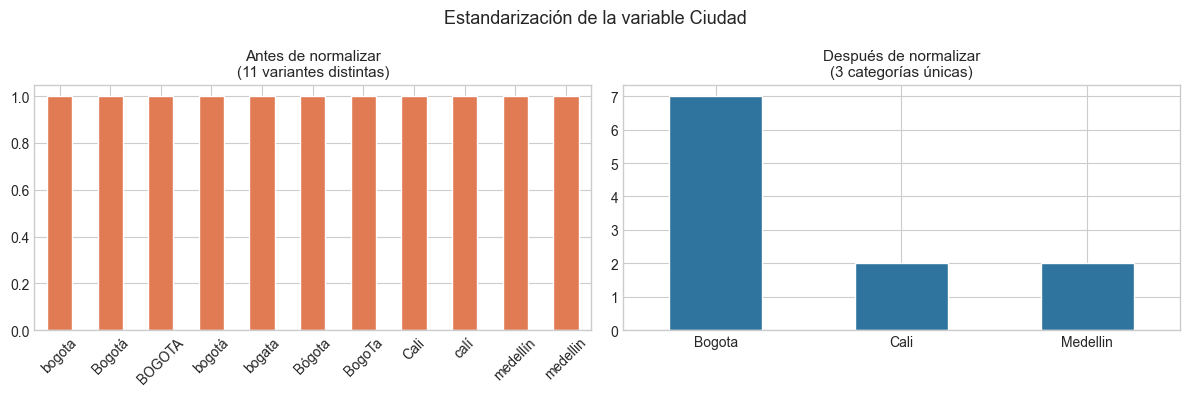

In [58]:
#  Visualización 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orig_counts = pd.DataFrame({'Ciudad': ['bogota','Bogotá','BOGOTA','bogotá','bogata',
                                        'Bógota','BogoTa','Cali','calí','medellín','medellin']})
orig_counts['Ciudad'].value_counts().plot.bar(ax=axes[0], color='#E07B54', edgecolor='white')
axes[0].set_title('Antes de normalizar\n(11 variantes distintas)', fontsize=11)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

df['Ciudad'].value_counts().plot.bar(ax=axes[1], color='#2F749F', edgecolor='white')
axes[1].set_title('Después de normalizar\n(3 categorías únicas)', fontsize=11)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Estandarización de la variable Ciudad', fontsize=13)
plt.tight_layout()
plt.show()


**Conclusión Ejercicio 3:** Mediante la combinación de tres técnicas (minúsculas + remoción de diacríticos + diccionario de correcciones + Title Case), las **11 variantes** de escritura se redujeron a **3 categorías limpias y únicas**: `Bogota`, `Cali` y `Medellin`. La remoción de tildes garantiza la robustez ante problemas de codificación UTF-8 / ASCII.

---
## <span style="color:#2F749F;"><strong>Ejercicio 4 — Identificación de Mecanismos de Datos Faltantes (MCAR, MAR, MNAR)</strong></span>

1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 3.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género. 
   - **Escenario 4.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.
   

*Escenario 1.* Para este caso nos enfrentamos ante un dato faltante tipo MCAR dado que el dato faltante de ingreso familiar no tiene relacion con ningun otra variable y lo hace de manera completamente aleatoria.

*Escenario 2.* Para este caso podemos decir que se trata de un tipo de dato MAR dado que la probabilidad de que falte "Horas de estudio" está relacionada con el Promedio académico, una variable observada. Una vez controlado el Promedio, la ausencia es aleatoria.

*Escenario 3.* Para este escenario, tambien se trata de un dato faltante tipo MAR dado que presenta relacion con otra de las variables pero no es de manera intencionada, sino aleatoria.

*Escenario 4.* Con respecto a este escenario, el tipo de dato faltante corresponde a MNAR dado que el valor faltante en "Horas de estudio" depende del propio valor de esa variable ya que los estudiantes ocultan el dato precisamente porque es bajo. La ausencia no es aleatoria ni explicable por otras variables observadas.

---
## <span style="color:#2F749F;"><strong>Ejercicio 5 — Imputación con KNN y Regresión</strong></span>

In [59]:
# Crear el dataframe
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

# Guardar copia del df original para comparación posterior
df_ej5 = df.copy()

# Vista general del DataFrame con valores faltantes
print('=== DataFrame con valores faltantes ===')
display(df_ej5)

=== DataFrame con valores faltantes ===


,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.00,2909818.00,7
1,46,2.27,NaN,3031785.00,7
2,32,NaN,30.00,5283302.00,9
3,25,3.15,14.00,NaN,3
4,38,4.95,7.00,3525928.00,7
5,56,NaN,13.00,4653339.00,1
6,36,4.58,22.00,NaN,4
7,40,4.04,NaN,1879111.00,4
8,28,NaN,20.00,1796107.00,5
9,28,2.04,15.00,4321441.00,7


Variables con datos faltantes:


,Nulos,% Faltante
Promedio,4,13.30
Horas_estudio,4,13.30
Ingreso_familiar,3,10.00


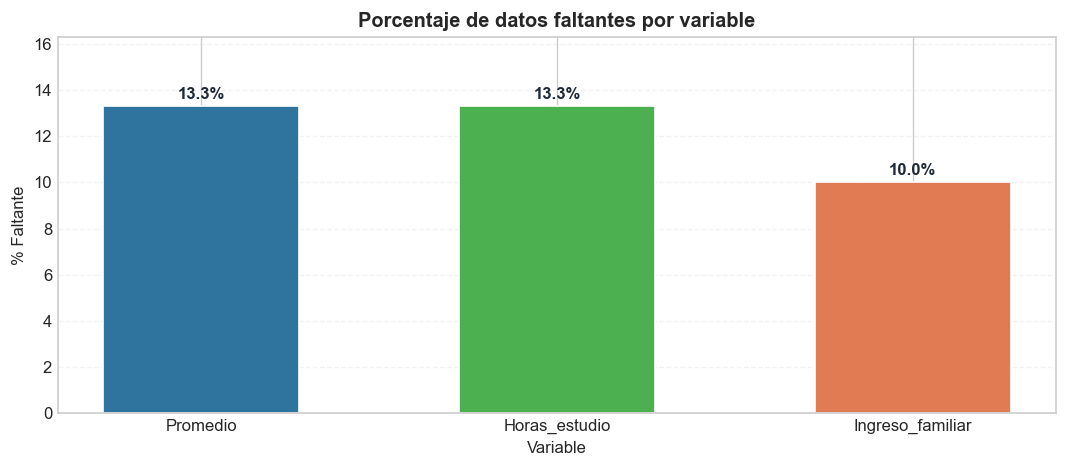

In [60]:
# Reporte de valores faltantes + gráfica de porcentaje
nulos_df = df_ej5.isnull().sum()
pct_df   = (nulos_df / n * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos_df, '% Faltante': pct_df})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('% Faltante', ascending=False)

print('Variables con datos faltantes:')
display(resumen_nulos)

fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
bars = ax.bar(
    resumen_nulos.index,
    resumen_nulos['% Faltante'],
    color=['#2F749F', '#4CAF50', '#E07B54'],
    edgecolor='white', linewidth=1.0, width=0.55
)
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.2,
        f'{b.get_height():.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1F2937'
    )
ax.set_title('Porcentaje de datos faltantes por variable', fontsize=12, fontweight='bold')
ax.set_ylabel('% Faltante')
ax.set_xlabel('Variable')
ax.set_ylim(0, max(resumen_nulos['% Faltante']) + 3)
ax.grid(axis='y', alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

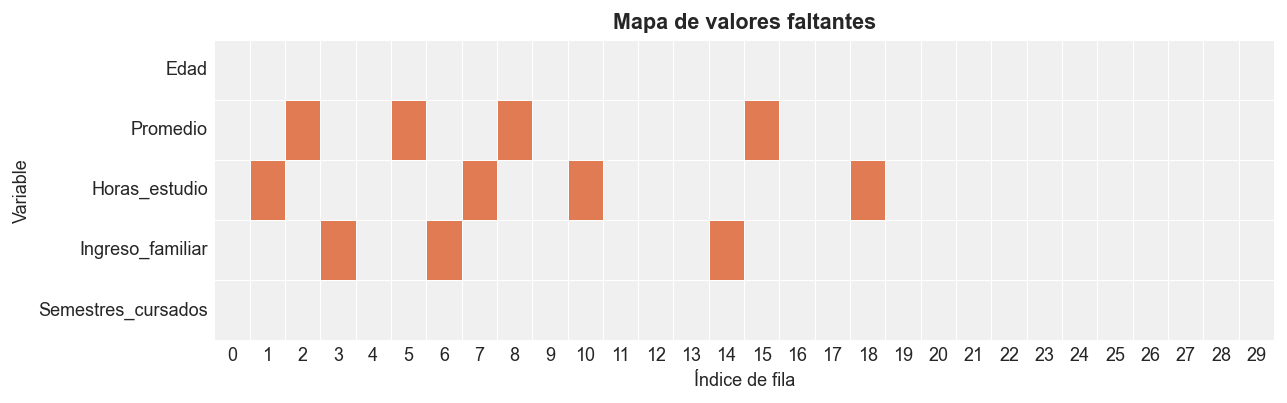

In [61]:
# Heatmap de faltantes (celda dedicada)
fig, ax = plt.subplots(figsize=(10, 3.2), dpi=130)
sns.heatmap(
    df_ej5.isnull().T,
    cbar=False,
    cmap=['#F0F0F0', '#E07B54'],
    ax=ax,
    linewidths=0.3,
    linecolor='white'
)
ax.set_title('Mapa de valores faltantes', fontsize=12, fontweight='bold')
ax.set_xlabel('Índice de fila')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

**Respuestas:**

- **¿Qué variables tienen mayor proporción de datos faltantes?**  
  Promedio y Horas_estudio tienen la mayor proporción con 4 nulos cada una (13.3 %), seguidas de Ingreso_familiar con 3 nulos (10 %). 
  Las variables Edad y Semestres_cursados están completas.

- **¿Observas algún patrón estructurado o parecen aleatorios?**  
  Los datos faltantes se introdujeron en índices fijos y no se solapan entre variables. Esto indica un patrón artificial. En un escenario real, esta distribución sin solapamiento y condicionada a otras variables sugeriría un mecanismo **MAR** 

### Paso 3 — Imputación con KNN

In [62]:
# Imputación con KNN (k=5 vecinos más cercanos)
from sklearn.impute import KNNImputer

cols_num = ['Edad', 'Promedio', 'Horas_estudio', 'Ingreso_familiar', 'Semestres_cursados']

df_knn = df_ej5.copy()
imputer_knn = KNNImputer(n_neighbors=5)
df_knn[cols_num] = imputer_knn.fit_transform(df_knn[cols_num])

# Redondear para preservar el tipo entero en las variables correspondientes
df_knn['Horas_estudio'] = df_knn['Horas_estudio'].round(0).astype(int)
df_knn['Ingreso_familiar'] = df_knn['Ingreso_familiar'].round(0).astype(int)
df_knn['Promedio'] = df_knn['Promedio'].round(2)

print('=== DataFrame imputado con KNN ===')
display(df_knn)
print(f'\nNulos restantes: {df_knn.isnull().sum().sum()}')

print('\n=== Valores imputados con KNN === \n')
print('  Promedio (filas 2,5,8,15):         ', df_knn.loc[[2,5,8,15], 'Promedio'].values)
print('  Horas_estudio (filas 1,7,10,18):   ', df_knn.loc[[1,7,10,18], 'Horas_estudio'].values)
print('  Ingreso_familiar (filas 3,6,14):   ', df_knn.loc[[3,6,14], 'Ingreso_familiar'].values)

=== DataFrame imputado con KNN ===


,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56.00,2.70,35,2909818,7.00
1,46.00,2.27,21,3031785,7.00
2,32.00,3.49,30,5283302,9.00
3,25.00,3.15,14,3558189,3.00
4,38.00,4.95,7,3525928,7.00
5,56.00,3.26,13,4653339,1.00
6,36.00,4.58,22,4301437,4.00
7,40.00,4.04,20,1879111,4.00
8,28.00,3.75,20,1796107,5.00
9,28.00,2.04,15,4321441,7.00



Nulos restantes: 0

=== Valores imputados con KNN === 

  Promedio (filas 2,5,8,15):          [3.49 3.26 3.75 3.49]
  Horas_estudio (filas 1,7,10,18):    [21 20 13 14]
  Ingreso_familiar (filas 3,6,14):    [3558189 4301437 3511210]


### Paso 3 — Imputación con Regresión Lineal

In [63]:
# Imputación con Regresión Lineal
# Para cada variable objetivo se entrena un modelo con las filas completas
# y se predicen los valores faltantes.

from sklearn.linear_model import LinearRegression

df_reg = df_ej5.copy()

variables_obj = {
    'Promedio': ['Edad', 'Horas_estudio', 'Ingreso_familiar', 'Semestres_cursados'],
    'Horas_estudio': ['Edad', 'Promedio', 'Ingreso_familiar', 'Semestres_cursados'],
    'Ingreso_familiar': ['Edad', 'Promedio', 'Horas_estudio', 'Semestres_cursados'],
}

for target, predictores in variables_obj.items():
    mask_faltante = df_reg[target].isna()
    df_train = df_reg.dropna(subset=[target] + predictores)

    lr = LinearRegression()
    lr.fit(df_train[predictores], df_train[target])

    mask_pred = mask_faltante & df_reg[predictores].notna().all(axis=1)
    df_reg.loc[mask_pred, target] = lr.predict(df_reg.loc[mask_pred, predictores])

# Redondear variables de tipo entero
df_reg['Horas_estudio'] = df_reg['Horas_estudio'].round(0).astype(int)
df_reg['Ingreso_familiar'] = df_reg['Ingreso_familiar'].round(0).astype(int)
df_reg['Promedio'] = df_reg['Promedio'].round(2)

print('=== DataFrame imputado con Regresión Lineal ===')
display(df_reg)
print(f'\nNulos restantes: {df_reg.isnull().sum().sum()}')

print('\n=== Valores imputados con Regresión === \n')
print('  Promedio (filas 2,5,8,15):         ', df_reg.loc[[2,5,8,15], 'Promedio'].values)
print('  Horas_estudio (filas 1,7,10,18):   ', df_reg.loc[[1,7,10,18], 'Horas_estudio'].values)
print('  Ingreso_familiar (filas 3,6,14):   ', df_reg.loc[[3,6,14], 'Ingreso_familiar'].values)

=== DataFrame imputado con Regresión Lineal ===


,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35,2909818,7
1,46,2.27,20,3031785,7
2,32,3.26,30,5283302,9
3,25,3.15,14,4409997,3
4,38,4.95,7,3525928,7
5,56,3.03,13,4653339,1
6,36,4.58,22,4205366,4
7,40,4.04,22,1879111,4
8,28,3.45,20,1796107,5
9,28,2.04,15,4321441,7



Nulos restantes: 0

=== Valores imputados con Regresión === 

  Promedio (filas 2,5,8,15):          [3.26 3.03 3.45 2.95]
  Horas_estudio (filas 1,7,10,18):    [20 22 14 17]
  Ingreso_familiar (filas 3,6,14):    [4409997 4205366 4119711]


### Paso 4 — ¿Se preserva la naturaleza de los datos?

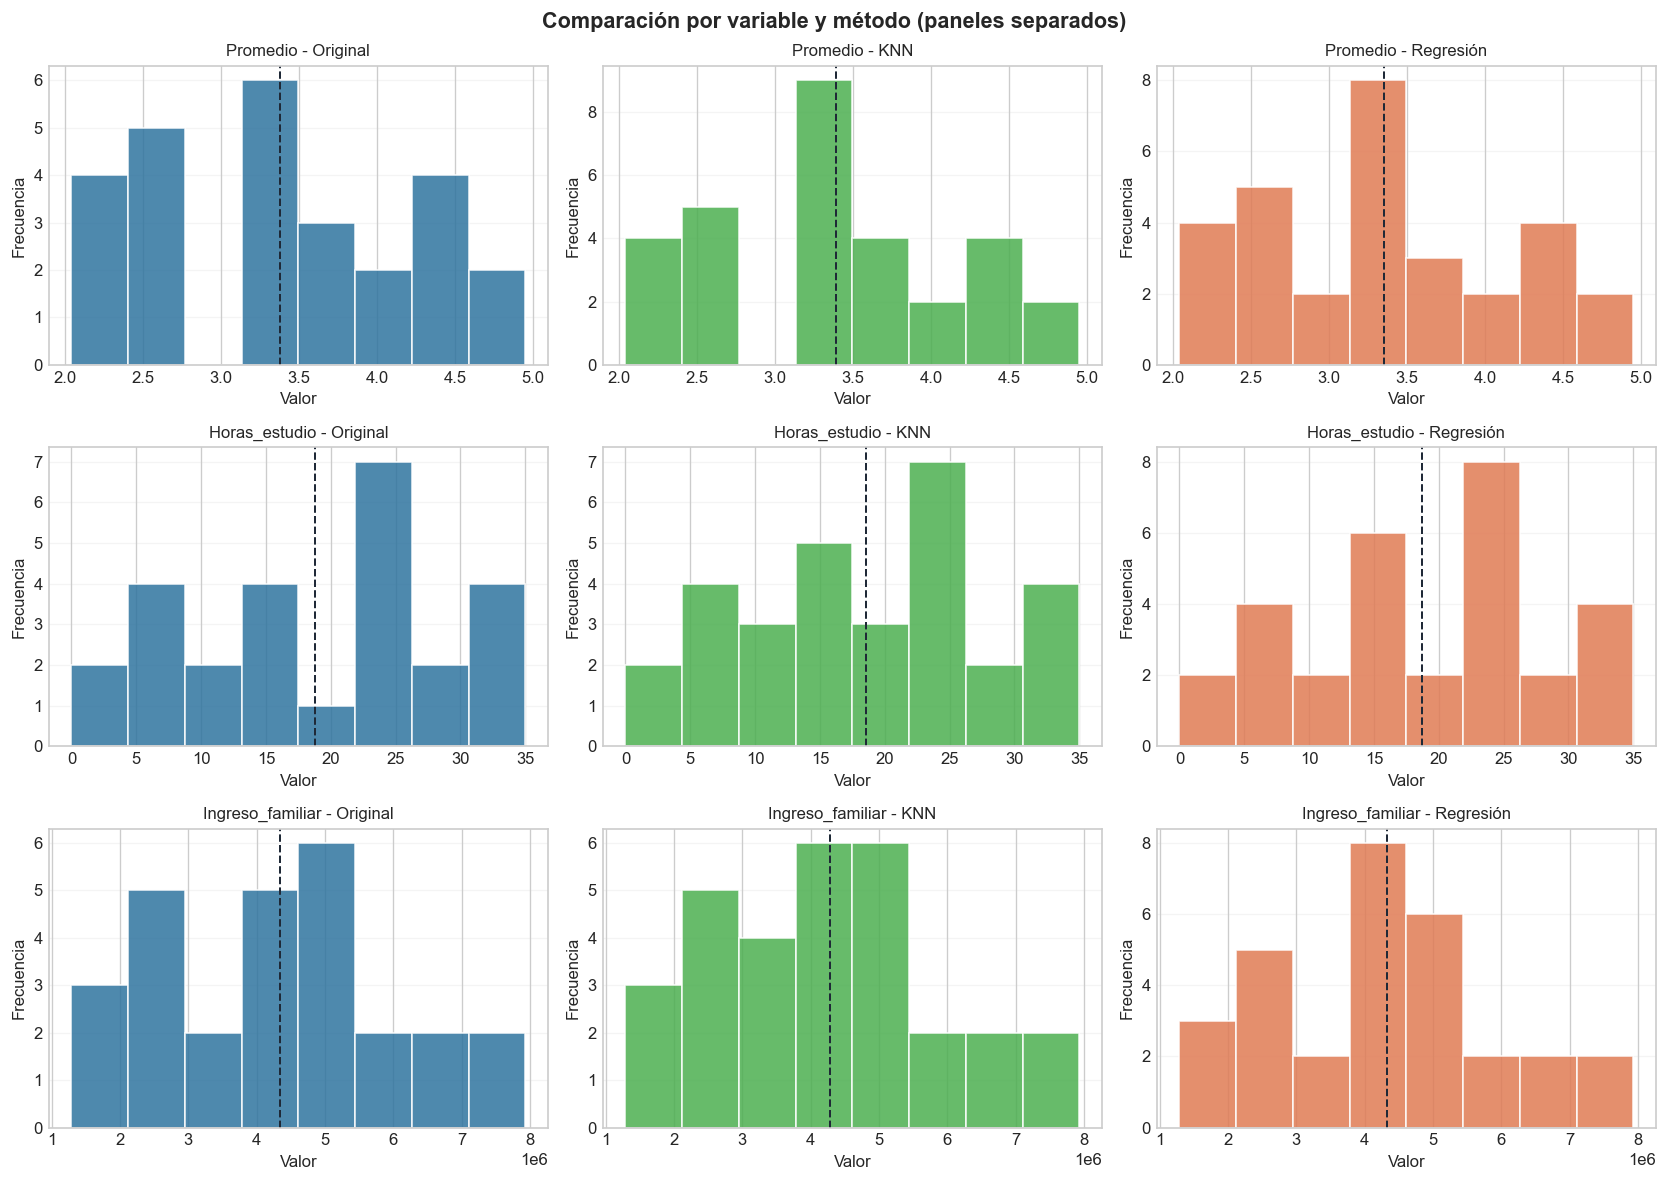

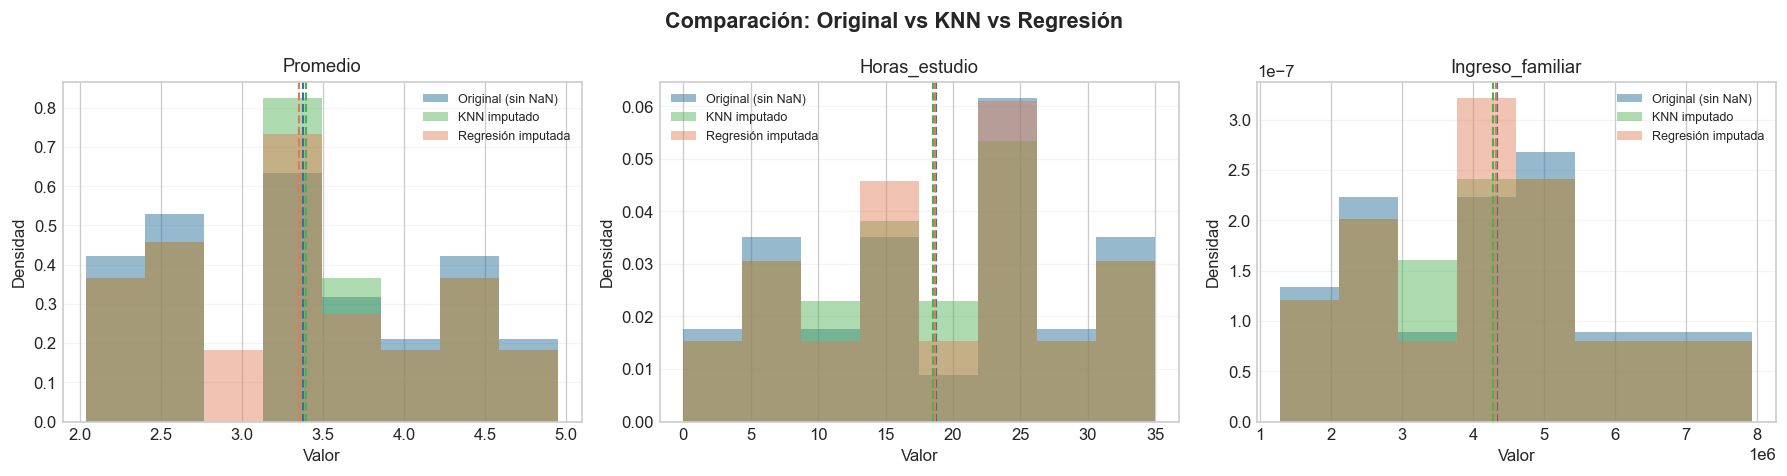


=== Estadísticas descriptivas por método ===

--- Promedio ---


,Original (sin NaN),KNN imputado,Regresión imputada
mean,3.38,3.39,3.35
std,0.90,0.84,0.84
min,2.04,2.04,2.04
max,4.95,4.95,4.95



--- Horas_estudio ---


,Original (sin NaN),KNN imputado,Regresión imputada
mean,18.77,18.53,18.70
std,10.37,9.73,9.69
min,0.00,0.00,0.00
max,35.00,35.00,35.00



--- Ingreso_familiar ---


,Original (sin NaN),KNN imputado,Regresión imputada
mean,4339501.26,4284579.00,4330053.60
std,1752490.65,1671869.50,1660083.11
min,1291234.00,1291234.00,1291234.00
max,7930144.00,7930144.00,7930144.00


In [64]:
# Comparación visual más legible: paneles separados + paneles solapados
vars_imputadas = ['Promedio', 'Horas_estudio', 'Ingreso_familiar']
colores = {
    'Original': '#2F749F',
    'KNN': '#4CAF50',
    'Regresión': '#E07B54'
}

# 1) Gráficos separados (sin solapar): uno por variable y por método
fig_sep, axes_sep = plt.subplots(3, 3, figsize=(14, 10), dpi=120)

for i, var in enumerate(vars_imputadas):
    datos = [
        ('Original', df_ej5[var].dropna()),
        ('KNN', df_knn[var]),
        ('Regresión', df_reg[var])
    ]

    for j, (metodo, serie) in enumerate(datos):
        ax = axes_sep[i, j]
        ax.hist(serie, bins=8, color=colores[metodo], alpha=0.85, edgecolor='white')
        ax.axvline(serie.mean(), color='#1F2937', linestyle='--', linewidth=1.2)
        ax.set_title(f'{var} - {metodo}', fontsize=10)
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frecuencia')
        ax.grid(axis='y', alpha=0.2)

plt.suptitle('Comparación por variable y método (paneles separados)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2) Gráficos solapados (uno por variable)
fig_ov, axes_ov = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

for ax, var in zip(axes_ov, vars_imputadas):
    orig_vals = df_ej5[var].dropna()
    knn_vals  = df_knn[var]
    reg_vals  = df_reg[var]

    ax.hist(orig_vals, bins=8, alpha=0.50, color=colores['Original'], label='Original (sin NaN)', density=True)
    ax.hist(knn_vals,  bins=8, alpha=0.45, color=colores['KNN'],      label='KNN imputado', density=True)
    ax.hist(reg_vals,  bins=8, alpha=0.45, color=colores['Regresión'], label='Regresión imputada', density=True)

    ax.axvline(orig_vals.mean(), color=colores['Original'], linestyle='--', linewidth=1.3)
    ax.axvline(knn_vals.mean(),  color=colores['KNN'], linestyle='--', linewidth=1.3)
    ax.axvline(reg_vals.mean(),  color=colores['Regresión'], linestyle='--', linewidth=1.3)

    ax.set_title(f'{var}', fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=7.5, frameon=False)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Comparación: Original vs KNN vs Regresión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen de estadísticas descriptivas por método
print('\n=== Estadísticas descriptivas por método ===')
for var in vars_imputadas:
    print(f'\n--- {var} ---')
    resumen = pd.DataFrame({
        'Original (sin NaN)': df_ej5[var].dropna().describe(),
        'KNN imputado': df_knn[var].describe(),
        'Regresión imputada': df_reg[var].describe(),
    }).round(2)
    display(resumen.loc[['mean', 'std', 'min', 'max']])

**Conclusión Numeral 4 — Análisis comparativo KNN vs Regresión**

| Criterio | KNN | Regresión lineal |
|---|---|---|
| **Naturaleza de variables enteras** (Horas_estudio, Ingreso_familiar) | Se preserva tras redondeo | Se preserva tras redondeo |
| **Rango válido** (Promedio entre 2.0 y 5.0) | Generalmente respetado | Puede extrapolar levemente fuera del rango |
| **Distribución / variabilidad** | Conserva mejor la forma y la variabilidad local (promedia vecinos reales) | Tiende a suavizar y concentrar valores alrededor de la media condicional |
| **Varianza** | Más cercana a la original (depende de `k`) | Menor, con posible *regression to the mean* |
| **Valores extremos** | Los preserva mejor si existen vecinos extremos | Tiende a evitar extremos y acercarse al centro |
| **Sensibilidad a outliers** | Más alta (puede verse afectado por vecinos atípicos) | Moderada (ajuste global de la recta) |
| **Supuesto de linealidad** | No requiere | Sí requiere relación lineal entre predictores y variable objetivo |
| **Cuándo conviene más** | Cuando interesa preservar estructura local y forma de la distribución | Cuando hay relación lineal clara y se busca imputación estable |

**Conclusión general:** En este dataset (numérico y con pocos faltantes), ambos métodos preservan de forma aceptable la naturaleza de los datos. Sin embargo, **KNN** conserva mejor la dispersión y el rango observado, mientras que **regresión lineal** puede subestimar la variabilidad al producir valores más cercanos a la media.

---
## <span style="color:#2F749F;"><strong>Ejercicio 6 — Imputación con LOCF y NOCB</strong></span>

In [65]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
    'Ventas': np.round(np.random.uniform(100, 500, n), 2),
    'Inventario': np.random.randint(10, 100, n),
    'Clientes': np.random.randint(1, 50, n)
})

# Introducción de valores faltantes
df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
df.loc[[7, 8, 20], 'Inventario'] = np.nan
df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
df = df.sort_values('Fecha').reset_index(drop=True)

print('DataFrame de serie temporal (primeras 25 filas):')
display(df.head(25))

DataFrame de serie temporal (primeras 25 filas):


,Fecha,Ventas,Inventario,Clientes
0,2023-01-01,249.82,60.00,29.00
1,2023-01-02,480.29,16.00,NaN
2,2023-01-03,392.80,30.00,NaN
3,2023-01-04,NaN,82.00,44.00
4,2023-01-05,NaN,48.00,34.00
5,2023-01-06,NaN,27.00,10.00
6,2023-01-07,123.23,13.00,36.00
7,2023-01-08,446.47,NaN,14.00
8,2023-01-09,340.45,NaN,31.00
9,2023-01-10,383.23,23.00,48.00


In [ ]:
# Comparación visual de imputaciones: Original vs LOCF vs NOCB
vars_ts = ['Ventas', 'Inventario', 'Clientes']
fig, axes = plt.subplots(3, 1, figsize=(12, 10), dpi=120, sharex=True)

for ax, col in zip(axes, vars_ts):
    ax.plot(df['Fecha'], df[col], marker='o', linewidth=1.5, color='#9CA3AF', label='Original (con NaN)')
    ax.plot(df_locf['Fecha'], df_locf[col], marker='o', linewidth=1.8, color='#2F749F', label='LOCF')
    ax.plot(df_nocb['Fecha'], df_nocb[col], marker='o', linewidth=1.8, color='#E07B54', label='NOCB')

    ax.set_title(f'{col} — comparación de imputación', fontsize=11)
    ax.set_ylabel('Valor')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

axes[-1].set_xlabel('Fecha')
plt.suptitle('Ejercicio 6: imputación temporal con LOCF y NOCB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusión Ejercicio 6 — Método recomendado:**

Para este caso temporal, **LOCF** suele ser más apropiado cuando se busca una imputación coherente con un escenario de monitoreo en tiempo real, porque solo usa información pasada. **NOCB** puede ser útil en análisis retrospectivo, pero introduce riesgo de fuga de información futura si luego se modela en contexto predictivo.

En este DataFrame, ambos métodos son válidos técnicamente; sin embargo, por criterio temporal y causal, se recomienda **LOCF** como opción principal y **NOCB** como análisis de sensibilidad.